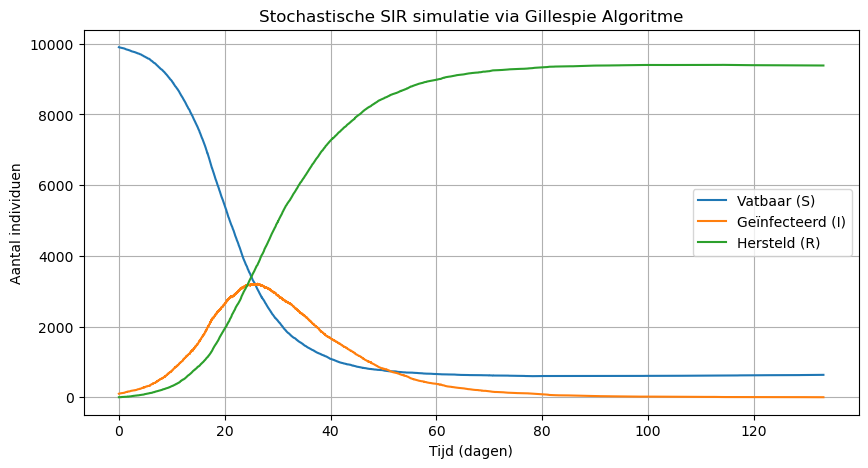

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max):
    # Initiële waarden
    t = 0.0
    X, Y, Z = X0, Y0, Z0
    
    # Lijsten voor de resultaten
    times = [t]
    X_history = [X]
    Y_history = [Y]
    Z_history = [Z]
    
    while t < t_max and Y > 0:
        # Bereken de rates (propensities) van elke gebeurtenis
        r1 = mu * N                  # Geboorte (X -> X + 1)
        r2 = beta * X * Y / N        # Infectie (X -> X-1, Y -> Y+1)
        r3 = gamma * Y               # Herstel (Y -> Y-1, Z -> Z+1)
        r4 = mu * X                  # Sterfte S (X -> X - 1)
        r5 = mu * Y                  # Sterfte I (Y -> Y - 1)
        r6 = mu * Z                  # Sterfte R (Z -> Z - 1)
        
        rates = [r1, r2, r3, r4, r5, r6]
        R_total = sum(rates)
        
        if R_total == 0:
            break
            
        # 1. Bepaal de tijd tot de volgende gebeurtenis (Exponentiële verdeling)
        u1 = np.random.uniform(0, 1)
        dt = -np.log(u1) / R_total
        t += dt
        
        # 2. Bepaal welke gebeurtenis plaatsvindt
        u2 = np.random.uniform(0, 1)
        probabilities = [r / R_total for r in rates]
        event = np.random.choice(6, p=probabilities)
        
        # 3. Voer de gekozen gebeurtenis uit
        if event == 0:    # Geboorte
            X += 1
        elif event == 1:  # Infectie
            X -= 1
            Y += 1
        elif event == 2:  # Herstel
            Y -= 1
            Z += 1
        elif event == 3:  # Sterfte X
            X -= 1
        elif event == 4:  # Sterfte Y
            Y -= 1
        elif event == 5:  # Sterfte Z
            Z -= 1
            
        # Bewaar de toestand
        times.append(t)
        X_history.append(X)
        Y_history.append(Y)
        Z_history.append(Z)
        
    return np.array(times), np.array(X_history), np.array(Y_history), np.array(Z_history)

# Voorbeeld van een simulatie run:
N = 10000
R0 = 3.0
gamma = 1/10  # herstelperiode van 10 dagen
beta = R0 * gamma
mu = 0.0001   # geboorte/sterfte cijfer

X0, Y0, Z0 = 9900, 100, 0
t_max = 365

times, X, Y, Z = gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max)

# Plotten
plt.figure(figsize=(10, 5))
plt.plot(times, X, label='Vatbaar (S)')
plt.plot(times, Y, label='Geïnfecteerd (I)')
plt.plot(times, Z, label='Hersteld (R)')
plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal individuen')
plt.title('Stochastische SIR simulatie via Gillespie Algoritme')
plt.legend()
plt.grid(True)
plt.show()